假设 batch_size 为 $m = 2$，两个输入的序列长度分别为 1 和 10，模型的输入尺寸为 `[2, 10, hidden_dim]`，理论上讲，BatchNorm 计算均值和方差应该针对这 11 个向量进行，但是由于第一个输入有 9 个位置都是 padding，所以直接对 `[2, 10, hidden_dim]` 的模型输入做 BatchNorm 实际将这 9 个 padding 也纳入到了均值和方差的计算过程中，显然不对。

LayerNorm，在做归一化时直接不考虑序列这一维度，只在每一个位置的特征 $h$ 内部自己做归一化，即**针对每一位置的维度为 $d$ 的特征单独计算均值和方差**，这样的话就可以避免序列长度不同对于归一化的影响。

**BatchNorm**:
$$
\begin{aligned}
\mu_B &= \frac{1}{m} \sum_{i=1}^{m} x_i \\
\sigma_B^2 &= \frac{1}{m} \sum_{i=1}^{m} (x_i - \mu_B)^2 \\
\hat{x}_i &= \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}} \\
y_i &= \gamma \hat{x}_i + \beta
\end{aligned}
$$

**LayerNorm**:
$$
\begin{aligned}
\mu_L &= \frac{1}{d} \sum_{i=1}^{d} x_i \\
\sigma_L^2 &= \frac{1}{d} \sum_{i=1}^{d} (x_i - \mu_L)^2 \\
\hat{x}_i &= \frac{x_i - \mu_L}{\sqrt{\sigma_L^2 + \epsilon}} \\
y_i &= \gamma \hat{x}_i + \beta
\end{aligned}
$$

**RMSNorm**:


$$
\begin{aligned}\mathbf{v} & =\left[v_{1}, v_{2}, \cdots, v_{d}\right] \\\operatorname{RMS}(\mathbf{v}) & =\sqrt{\frac{1}{d} \sum_{i=1}^{d} v_{i}^{2}} \\\forall i \in\{1, \cdots, d\}, o_{i} & =\frac{v_{i}}{\operatorname{RMS}(\mathbf{v})} g_{i}\end{aligned}
$$

In [1]:
import torch
import torch.nn as nn

batch_size = 2
seq_len = 10
hidden_dim = 512

x = torch.randn(batch_size, seq_len, hidden_dim) * 1.5 + 2.0

In [2]:
batch_norm = nn.BatchNorm1d(hidden_dim)
x_bn = x.transpose(1, 2)
x_out = batch_norm(x_bn).transpose(1, 2)
x_out.shape

torch.Size([2, 10, 512])

In [3]:
layer_norm = nn.LayerNorm(hidden_dim)
x_out = layer_norm(x)
x_out.shape

torch.Size([2, 10, 512])

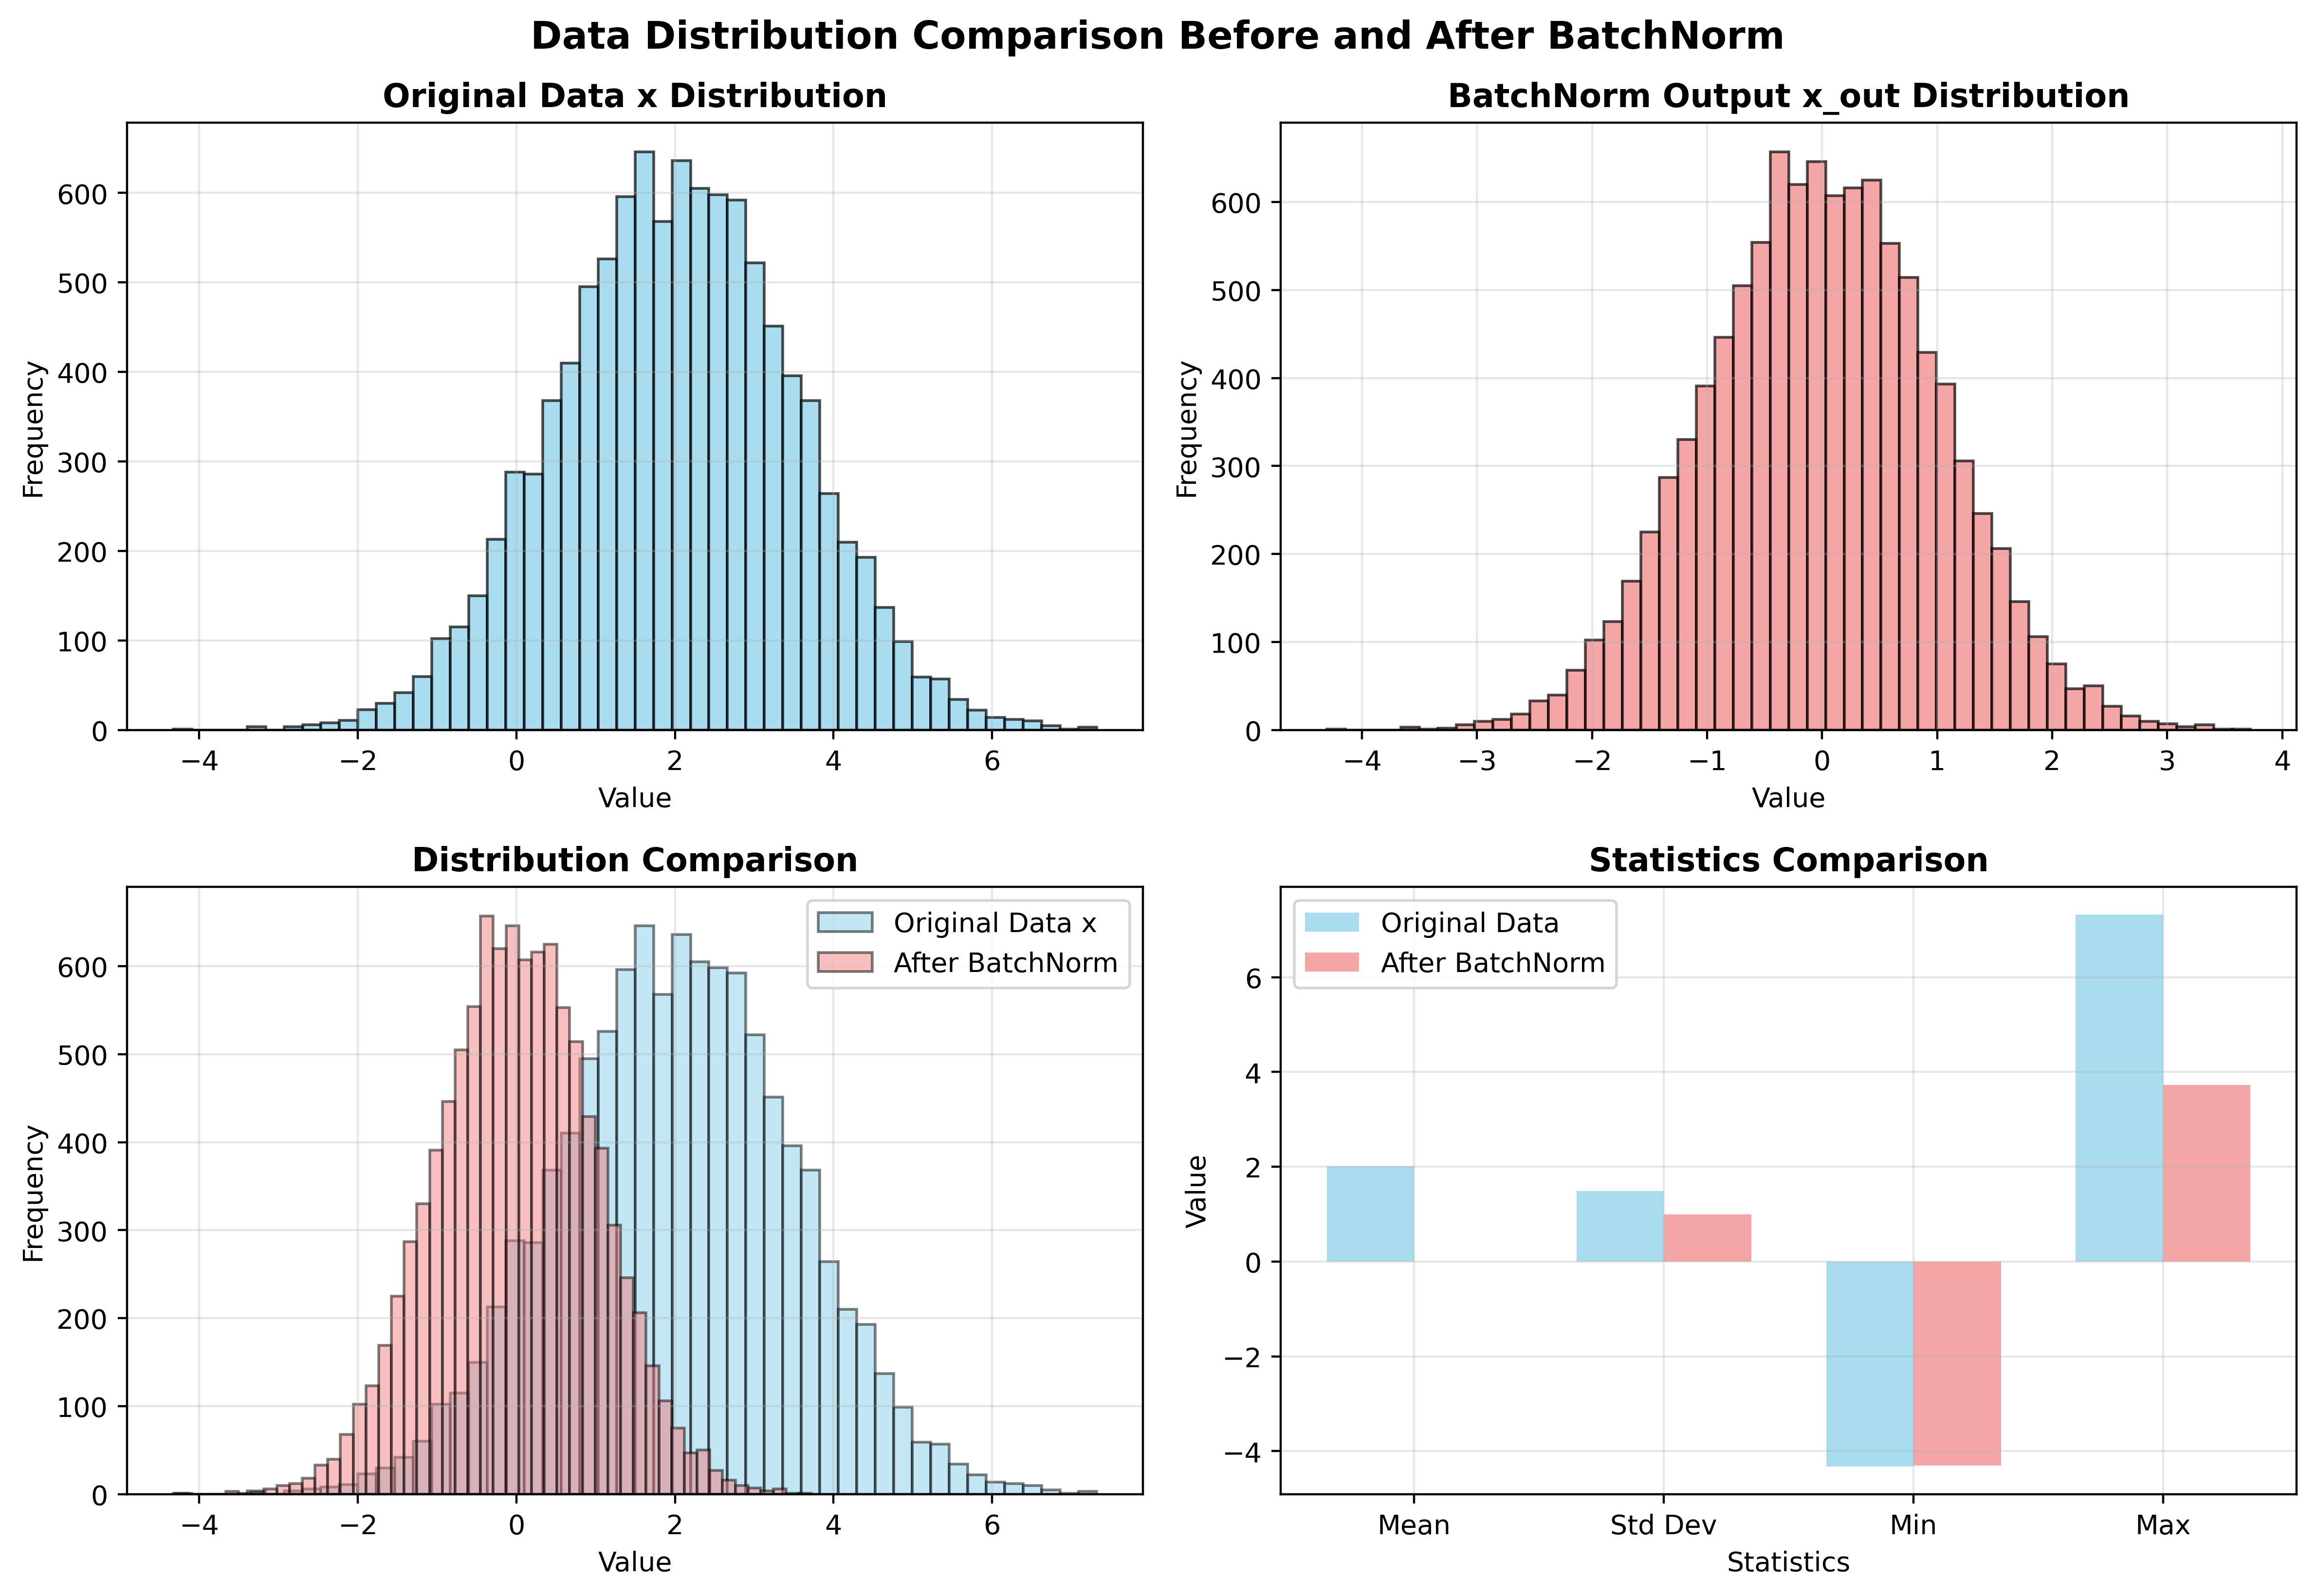

Original data x:
  Shape: torch.Size([2, 10, 512])
  Mean: 2.012973
  Std Dev: 1.489705
  Min: -4.326281
  Max: 7.321486

After BatchNorm x_out:
  Shape: torch.Size([2, 10, 512])
  Mean: -0.000000
  Std Dev: 0.999998
  Min: -4.304884
  Max: 3.724513


In [5]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Original data x distribution
x_flat = x.flatten().detach().numpy()
axes[0, 0].hist(x_flat, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Original Data x Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# BatchNorm output x_out distribution
x_bn_flat = x_out.flatten().detach().numpy()
axes[0, 1].hist(x_bn_flat, bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('BatchNorm Output x_out Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Value')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# Distribution comparison
axes[1, 0].hist(x_flat, bins=50, alpha=0.5, color='skyblue', label='Original Data x', edgecolor='black')
axes[1, 0].hist(x_bn_flat, bins=50, alpha=0.5, color='lightcoral', label='After BatchNorm', edgecolor='black')
axes[1, 0].set_title('Distribution Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Value')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Statistics comparison
stats_data = {
    'Mean': [x_flat.mean(), x_bn_flat.mean()],
    'Std Dev': [x_flat.std(), x_bn_flat.std()],
    'Min': [x_flat.min(), x_bn_flat.min()],
    'Max': [x_flat.max(), x_bn_flat.max()]
}

x_pos = np.arange(len(stats_data))
width = 0.35

for i, (stat_name, values) in enumerate(stats_data.items()):
    axes[1, 1].bar(i - width/2, values[0], width, label='Original Data' if i == 0 else "", 
                   color='skyblue', alpha=0.7)
    axes[1, 1].bar(i + width/2, values[1], width, label='After BatchNorm' if i == 0 else "", 
                   color='lightcoral', alpha=0.7)

axes[1, 1].set_title('Statistics Comparison', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Statistics')
axes[1, 1].set_ylabel('Value')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(stats_data.keys())
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Data Distribution Comparison Before and After BatchNorm', fontsize=14, fontweight='bold', y=1.02)
plt.gcf().set_dpi(400)
plt.show()

# Print detailed statistics
print(f"Original data x:")
print(f"  Shape: {x.shape}")
print(f"  Mean: {x_flat.mean():.6f}")
print(f"  Std Dev: {x_flat.std():.6f}")
print(f"  Min: {x_flat.min():.6f}")
print(f"  Max: {x_flat.max():.6f}")

print(f"\nAfter BatchNorm x_out:")
print(f"  Shape: {x_out.shape}")
print(f"  Mean: {x_bn_flat.mean():.6f}")
print(f"  Std Dev: {x_bn_flat.std():.6f}")
print(f"  Min: {x_bn_flat.min():.6f}")
print(f"  Max: {x_bn_flat.max():.6f}")

In [ ]:
import torch
import torch.nn as nn

class BatchNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(dim))
        self.beta = nn.Parameter(torch.zeros(dim))

    def forward(self, x):
        mean = torch.mean(x, dim=0, keepdim=True)
        var = torch.var(x, dim=0, unbiased=False, keepdim=True)
        return self.gamma * (x - mean / torch.sqrt(var + self.eps)) + self.beta

class LayerNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(dim))
        self.beta = nn.Parameter(torch.zeros(dim))

    def forward(self, x):
        mean = torch.mean(x, dim=-1, keepdim=True)
        var = torch.var(x, dim=-1, unbiased=False, keepdim=True)
        return self.gamma * (x - mean / torch.sqrt(var + self.eps)) + self.beta

class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        rms = torch.sqrt(torch.mean(x ** 2, dim=-1, keepdim=True) + self.eps)
        return x / rms * self.weight

batch_size, seq_len, hidden_dim = 4, 10, 16
x = torch.randn(batch_size, seq_len, hidden_dim)

bn = BatchNorm(hidden_dim)
ln = LayerNorm(hidden_dim)
rms = RMSNorm(hidden_dim)

print("BatchNorm:", bn(x).shape)
print("LayerNorm:", ln(x).shape)
print("RMSNorm:", rms(x).shape)

如下是在一个完整的 Transformer 前向传播中的归一化模块插入。

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, hidden_dim, num_heads):
        super().__init__()
        self.attention = nn.MultiheadAttention(hidden_dim, num_heads, batch_first=True)
        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.ReLU(),
            nn.Linear(hidden_dim * 4, hidden_dim)
        )

        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.RMSNorm(hidden_dim)
    
    def forward(self, x, mask=None):
        # Pre-norm structure (commonly used in modern Transformer)
        attn_out, _ = self.attention(self.norm1(x), self.norm1(x), self.norm1(x), attn_mask=mask)
        x += attn_out
        ffn_out = self.ffn(self.norm2(x))
        x += ffn_out
        return x

# Test Transformer Block
block = TransformerBlock(hidden_dim, num_heads=8)
output = block(x, mask=torch.randn(32, 10, 10))
print(f"Transformer Block output shape: {output.shape}")

**残差连接**

ResNet 引入的残差连接（Residual Connection）形如：

$$x_{l+1} = x_l + F_l(x_l)$$

其中 $x_l \in \mathbb{R}^d$ 是第 $l$ 层的隐藏状态，$F_l$ 是该层的变换函数（如自注意力或前馈网络）。这一结构的核心思想是，梯度可以沿捷径路径（identity path）直接回传，从而缓解深层网络的梯度消失问题。

**PostNorm 与 PreNorm**

在 Transformer 中，层归一化（Layer Normalization, LN）与残差连接的**组合方式**存在两种主流范式：

**PostNorm**（原始 Transformer，Vaswani et al. 2017）：

$$x_{l+1} = \text{LN}(x_l + F_l(x_l))$$

归一化作用于残差相加之后的输出。

**PreNorm**（现代大语言模型的主流选择，如 GPT-2/3、LLaMA）：

$$x_{l+1} = x_l + F_l(\text{LN}(x_l))$$

归一化作用于进入子层 $F_l$ 之前的输入。

**PreNorm 的幅值增长问题**

对 PreNorm 进行递推展开。设共有 $L$ 个子层，则：

$$x_L = x_0 + \sum_{l=0}^{L-1} F_l\bigl(\text{LN}(x_l)\bigr)$$

这个式子揭示了一个关键性质：**残差流（residual stream）是一个纯累加结构**，每一层的输出以单位权重叠加到 $x_0$ 上，没有任何衰减因子。

现在考察 $\|x_l\|$ 的增长行为。LN 在进入 $F_l$ 之前将输入归一化，使得 $\|\text{LN}(x_l)\|$ 保持大致恒定（其范数约为 $\sqrt{d}$，$d$ 为维度）。因此，若假设各层输出的范数近似有界，即 $\|F_l(\text{LN}(x_l))\| \approx c$（$c$ 为某个正常数），则：

$$\|x_L\| \approx \|x_0\| + L \cdot c$$

**隐藏状态的幅值以 $O(L)$ 的速度线性增长。** 这在两方面造成问题：

**贡献稀释（contribution dilution）：** 第 $l$ 层对最终输出的相对贡献约为 $c / \|x_L\| \sim 1/L$，随着深度增加趋向于零。越浅的层在最终表示中占主导，越深的层贡献越被稀释。

**幅值爆炸（magnitude explosion）：** $\|x_L\|$ 随深度线性增长，这意味着在下游任务（如 softmax、线性分类头）中，logits 的尺度会随深度发生系统性偏移，影响训练稳定性和表达能力。

**与 PostNorm 的对比**

在 **PostNorm** 中，归一化作用于残差相加之后：

$$x_{l+1} = \text{LN}(x_l + F_l(x_l))$$

LN 每层都对输出进行重归一化，使得 $\|x_l\|$ 始终受控，不会随深度累积。但代价是：**梯度在经过 LN 时会受到缩放扰动**，导致深层网络（$L > 12$）训练初期极不稳定，通常需要 warmup 和精心设计的学习率调度。

**PreNorm** 则反过来：训练更稳定，梯度路径更干净，但输出幅值随深度增长，且学习到的表示在理论上存在浅层偏置（shallow layer bias）。

In [13]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
d = 128
L = 64
batch = 8
eps = 1e-5

def layer_norm(x):
    mean = x.mean(axis=-1, keepdims=True)
    std  = x.std(axis=-1, keepdims=True)
    return (x - mean) / (std + eps)

def sublayer_F(x, W):
    return x @ W

def make_weight():
    return np.random.randn(d, d) / np.sqrt(d)

weights = [make_weight() for _ in range(L)]
weights[0].shape

(128, 128)

实现 PreNorm。

In [25]:
x_pre = np.random.randn(batch, d)
norms_pre = [np.linalg.norm(x_pre, axis=-1).mean()]

for l in range(L):
    x_pre = x_pre + sublayer_F(layer_norm(x_pre), weights[l])
    norms_pre.append(np.linalg.norm(x_pre, axis=-1).mean())

norms_pre[0], norms_pre[-1]

(np.float64(11.374606655636367), np.float64(89.8940389948799))

实现 PostNorm。

In [27]:
x_post = np.random.randn(batch, d)
norms_post = [np.linalg.norm(x_post, axis=-1).mean()]

for l in range(L):
    x_post = layer_norm(x_post + sublayer_F(x_post, weights[l]))
    norms_post.append(np.linalg.norm(x_post, axis=-1).mean())

norms_post[0], norms_post[-1]

(np.float64(11.318455001780318), np.float64(11.313630811570414))

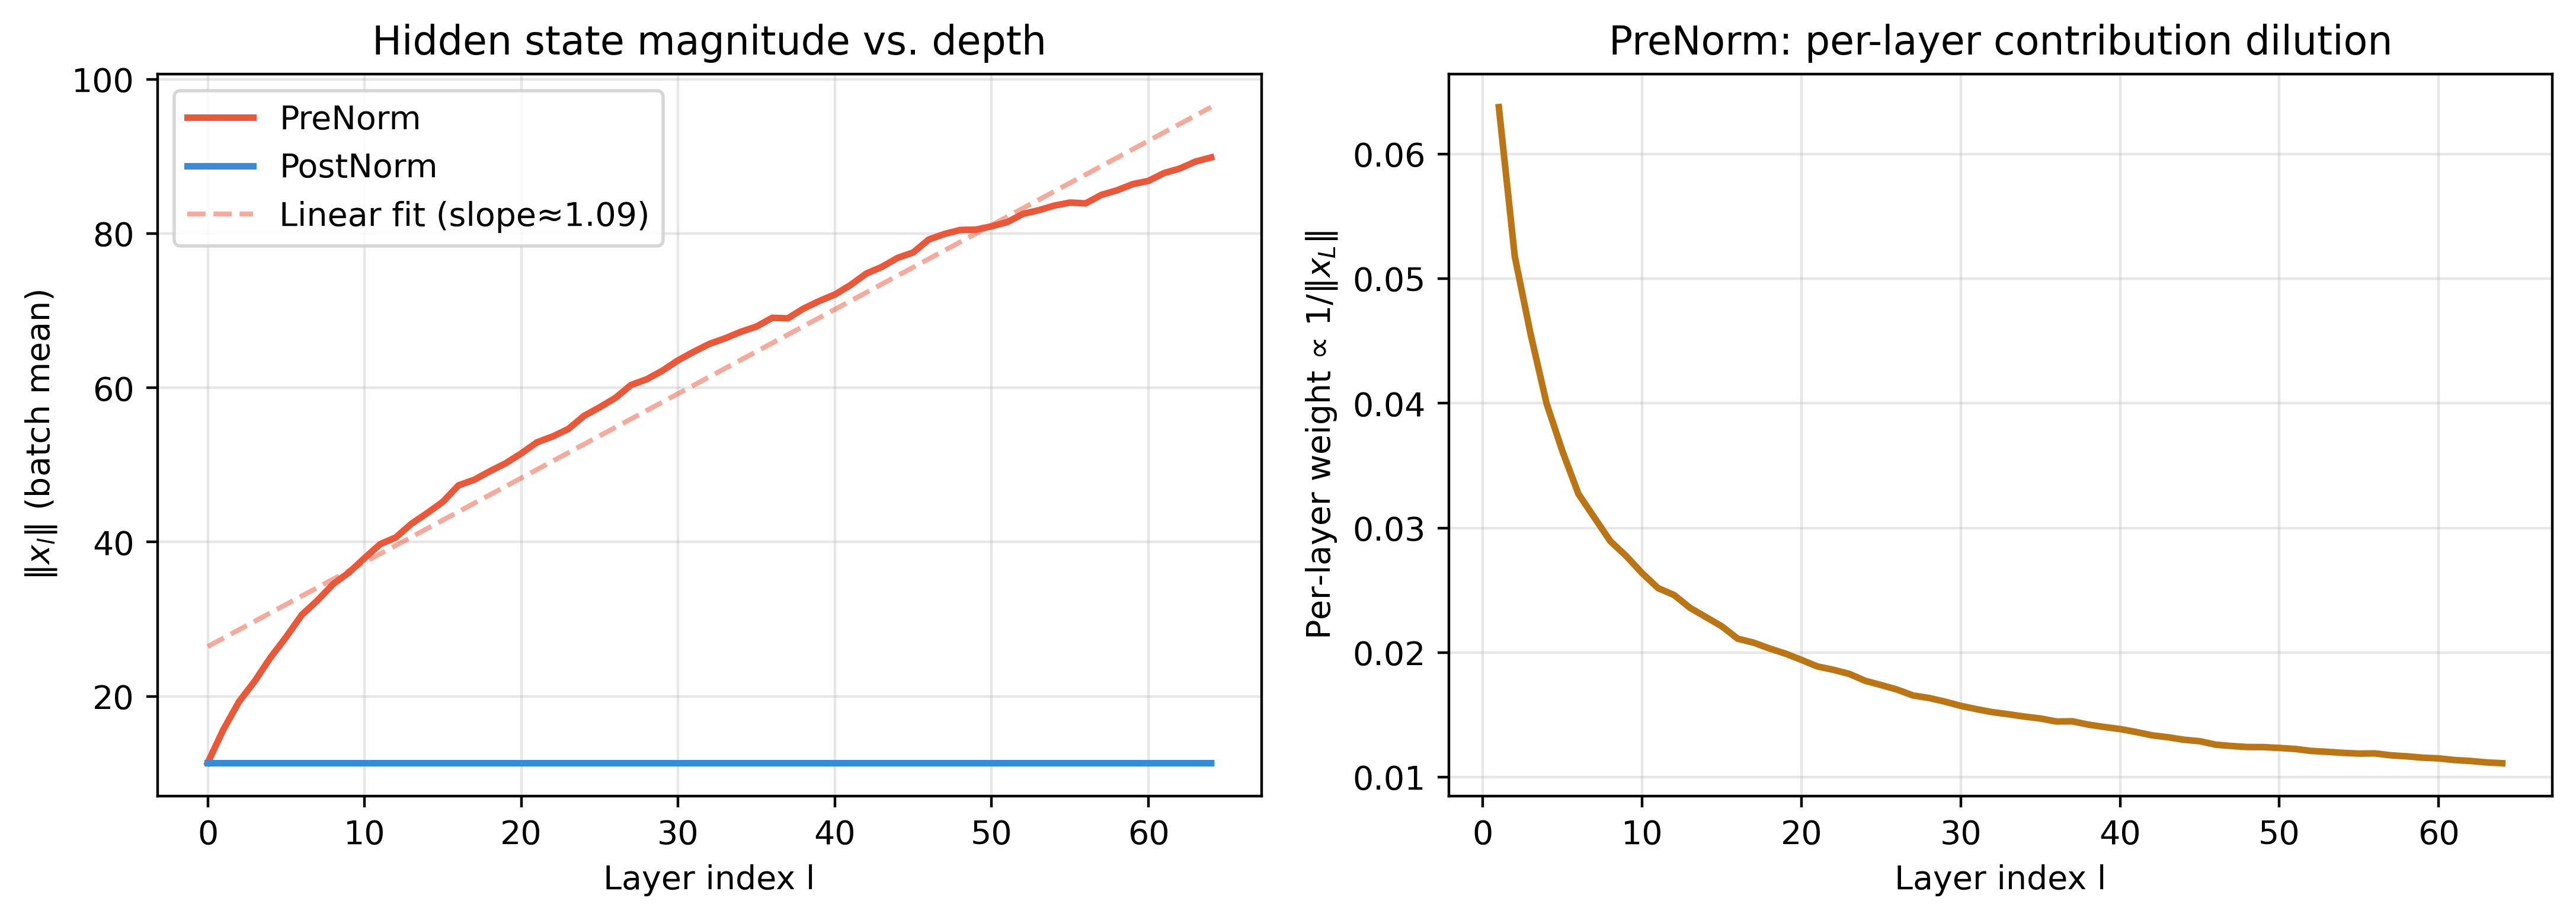

In [32]:
layers = np.arange(L + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(layers, norms_pre,  color='#E8593C', linewidth=2, label='PreNorm')
ax.plot(layers, norms_post, color='#3B8BD4', linewidth=2, label='PostNorm')
fit = np.polyfit(layers, norms_pre, 1)
ax.plot(layers, np.polyval(fit, layers), '--', color='#E8593C', alpha=0.5,
        label=f'Linear fit (slope≈{fit[0]:.2f})')
ax.set_xlabel('Layer index l')
ax.set_ylabel('$‖x_{l}‖$ (batch mean)')
ax.set_title('Hidden state magnitude vs. depth')
ax.legend()
ax.grid(True, alpha=0.3)

ax2 = axes[1]
relative = [1.0 / (norms_pre[l+1] + 1e-8) for l in range(L)]
ax2.plot(layers[1:], relative, color='#BA7517', linewidth=2)
ax2.set_xlabel('Layer index l')
ax2.set_ylabel('Per-layer weight ∝ $1 / ‖ x_{L} ‖$')
ax2.set_title('PreNorm: per-layer contribution dilution')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.gcf().set_dpi(400)
plt.show()